# Univariate Analysis

In [11]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [2]:
dataset=pd.read_csv("clean_df.csv")

In [3]:
dataset

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,AvgMonthlySpend
0,Female,No,Yes,No,1,No,No,DSL,No,Yes,...,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,14.92
1,Male,No,No,No,34,Yes,No,DSL,Yes,No,...,No,No,No,One year,No,Mailed check,56.95,1889.50,No,53.99
2,Male,No,No,No,2,Yes,No,DSL,Yes,Yes,...,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,36.05
3,Male,No,No,No,45,No,No,DSL,Yes,No,...,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No,40.02
4,Female,No,No,No,2,Yes,No,Fiber optic,No,No,...,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,50.55
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,Male,No,Yes,Yes,24,Yes,Yes,DSL,Yes,No,...,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.50,No,79.62
7039,Female,No,Yes,Yes,72,Yes,Yes,Fiber optic,No,Yes,...,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.90,No,100.86
7040,Female,No,Yes,Yes,11,No,No,DSL,Yes,No,...,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No,28.87
7041,Male,Yes,Yes,No,4,Yes,Yes,Fiber optic,No,No,...,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.60,Yes,61.32


### Q1. What is the proportion of customers who churned?

In [4]:
churn_table = dataset['Churn'].value_counts().to_frame(name='Count')
churn_table['Percentage (%)'] = (churn_table['Count'] / len(dataset)) * 100
churn_table['Percentage (%)'] = churn_table['Percentage (%)'].round(2)
churn_table

,Count,Percentage (%)
Churn,,
No,5174,73.46
Yes,1869,26.54


<h5 style="color:darkblue;"> Most customers have not churned. Around 26.5% of customers have left the service.
Dataset is imbalanced.</h5>

### Q2. Which contract type is most common?

<Axes: xlabel='Contract'>

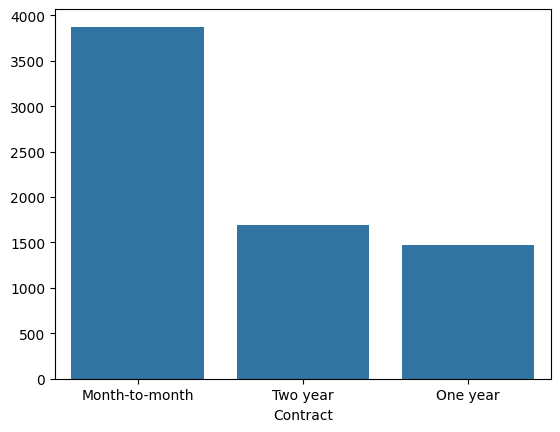

In [5]:
sns.barplot(x=dataset['Contract'].value_counts().index,
            y=dataset['Contract'].value_counts().values)

<h5 style="color:darkblue;"> Month-to-month contracts are the most common among customers. </h5>

### Q3. How are monthly charges distributed?

<Axes: xlabel='MonthlyCharges', ylabel='Count'>

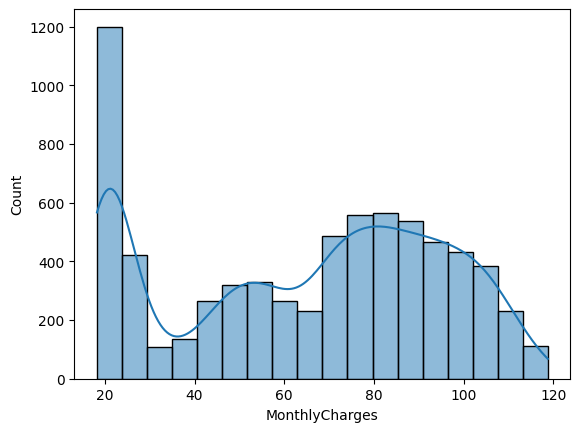

In [7]:
sns.histplot(dataset['MonthlyCharges'], kde=True)


<h5 style="color:darkblue;"> 
• Monthly charges are not evenly distributed.  <br>
• There are two main groups, one with lower charges (around 20–30) and another with higher charges (around 70–100). <br>
• This indicates that customers are likely divided based on different service plans, with some paying basic charges and others paying for more services. <br>
• The distribution is slightly right-skewed, showing fewer customers with very high charges. <br>
</h5> 

### Q4. Are there outliers in numerical variables?

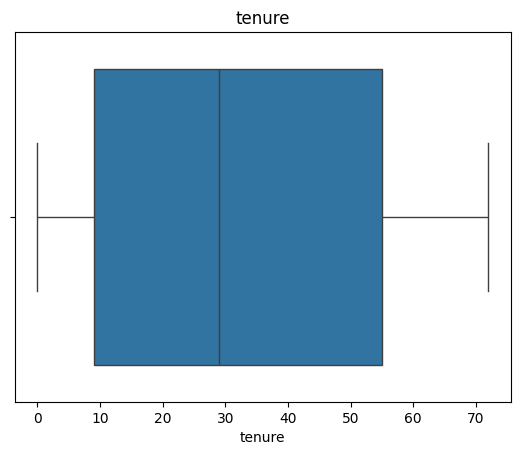

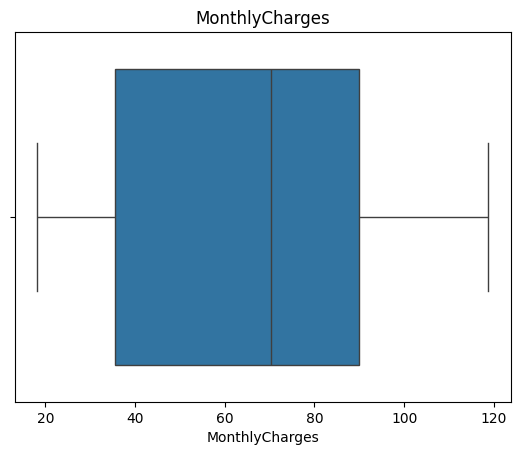

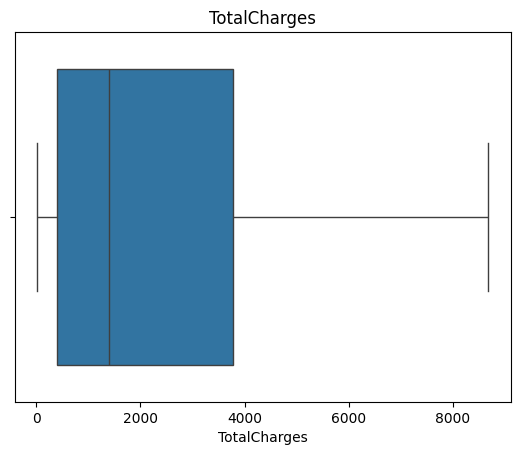

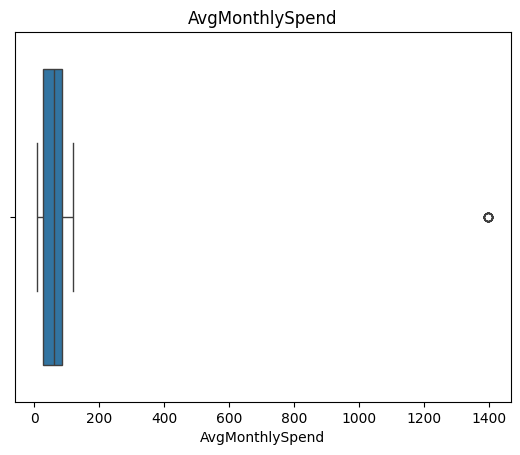

In [16]:
for col in ['tenure','MonthlyCharges','TotalCharges','AvgMonthlySpend']:
    sns.boxplot(x=dataset[col])
    plt.title(col)
    plt.show()

<h5 style="color:darkblue;"> • Outliers are present in some numerical variables, especially in TotalCharges and AvgMonthlySpend.<br> 
    • However, these values represent real customer behavior and are not errors, so they are retained for further analysis.</h5>

### Q5. How long do customers stay?

<Axes: xlabel='tenure', ylabel='Count'>

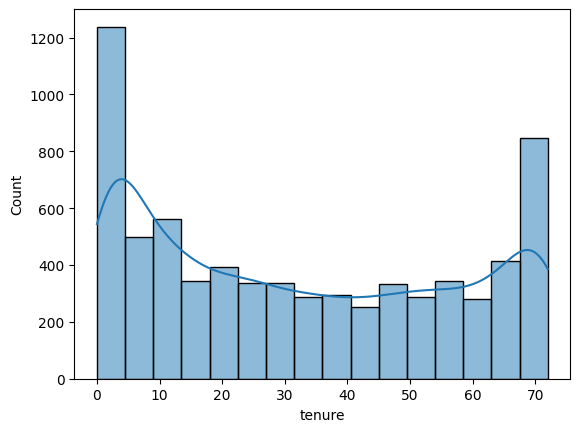

In [9]:
sns.histplot(dataset['tenure'], kde=True)

<h5 style="color:darkblue;"> The distribution shows that many customers are new, while another group stays for a long time, indicating that customers tend to either churn early or remain loyal over time. </h5>

### Q6. What is the distribution of average monthly spend?

<Axes: xlabel='AvgMonthlySpend', ylabel='Count'>

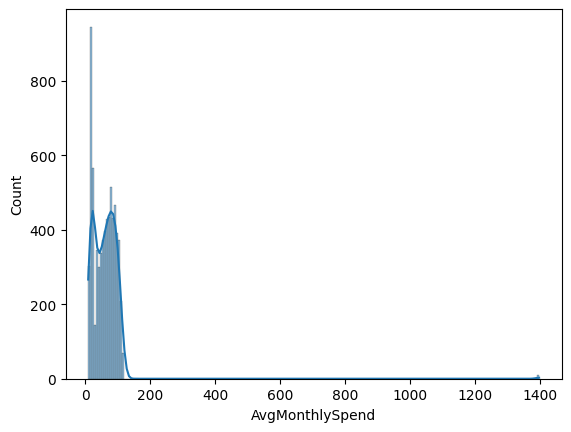

In [14]:
sns.histplot(dataset['AvgMonthlySpend'], kde=True)

<h5 style="color:darkblue;"> The distribution is highly right-skewed, with most customers having lower average spend and a few extreme high spenders.</h5>

### Q7. Are numerical variables normally distributed?

In [15]:
dataset[['tenure', 'MonthlyCharges','TotalCharges','AvgMonthlySpend']].skew()

tenure              0.239540
MonthlyCharges     -0.220524
TotalCharges        0.963789
AvgMonthlySpend    16.383751
dtype: float64

<h5 style="color:darkblue;"> 
• Most numerical variables are not perfectly normally distributed.  <br>
• Tenure and MonthlyCharges are slightly skewed, but still relatively balanced. <br>
• TotalCharges shows moderate right skew, while AvgMonthlySpend is highly right-skewed due to the presence of extreme values. <br>
• This indicates that the data does not follow a normal distribution. <br>
</h5>    

# Bivariate Analysis

### Q8. Does contract type affect churn?

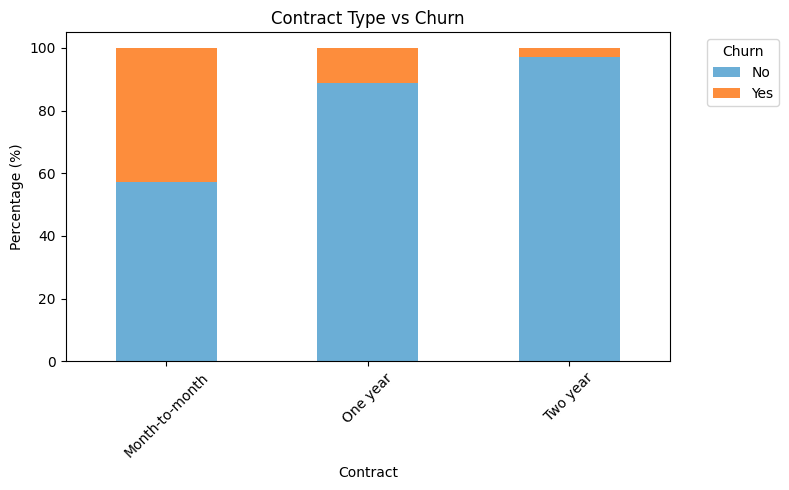

In [54]:
ct.plot(kind='bar', stacked=True, figsize=(8,5),
        color=['#6BAED6', '#FD8D3C'])

plt.xlabel('Contract')
plt.ylabel('Percentage (%)')
plt.title('Contract Type vs Churn')

plt.legend(title='Churn', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45)
    
plt.tight_layout()
plt.show()

<h5 style="color:darkblue;"> 
• Customers with month-to-month contracts have a significantly higher churn percentage compared to one-year and two-year contracts. <br>
• Two-year contract customers show the lowest churn, indicating that longer-term contracts improve customer retention. </h5>

### Q9. Do new customers churn more?

<Axes: xlabel='tenure', ylabel='Density'>

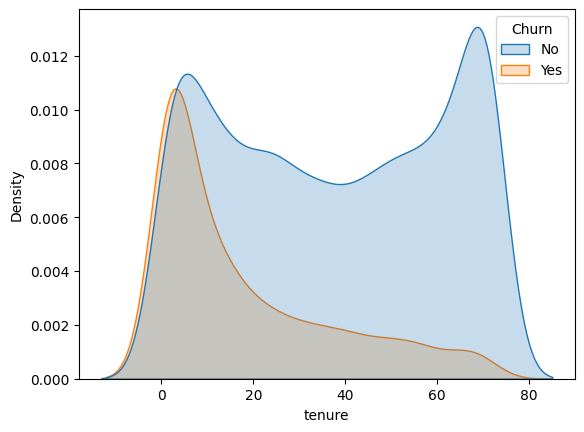

In [19]:
sns.kdeplot(data=dataset, x='tenure', hue='Churn', fill=True)

<h5 style="color:darkblue;"> 
• Customers with lower tenure are more likely to churn, indicating that new customers are at higher risk of leaving.<br> 
• As tenure increases, churn probability decreases, and long-term customers show strong retention.</h5> 

### Q10. Do higher charges influence churn?

<Axes: xlabel='Churn', ylabel='MonthlyCharges'>

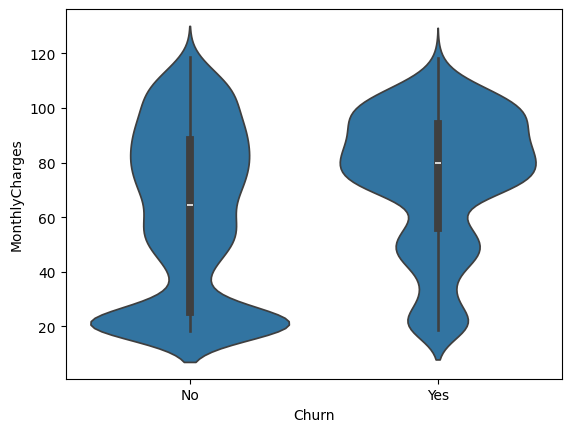

In [20]:
sns.violinplot(x='Churn', y='MonthlyCharges', data=dataset)

<h5 style="color:darkblue;"> 
• Customers with higher monthly charges tend to have higher churn, while those with lower charges are more likely to stay.<br> 
• This suggests that higher pricing may contribute to customer dissatisfaction.</h5> 

### Q11. Does spending behavior affect churn?

<Axes: xlabel='Churn', ylabel='AvgMonthlySpend'>

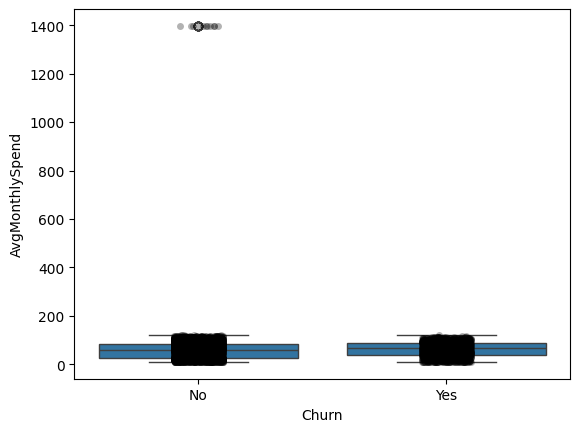

In [21]:
sns.boxplot(x='Churn', y='AvgMonthlySpend', data=dataset)
sns.stripplot(x='Churn', y='AvgMonthlySpend', data=dataset, color='black', alpha=0.3)

<h5 style="color:darkblue;"> 
• Customers who churn tend to have slightly higher average monthly spend compared to retained customers.<br> 
• Most retained customers have moderate spending, while churned customers show a slightly higher median and more spread.<br> 
• A few extreme outliers are present (~1400), but they do not represent typical customer behavior.<br> 
• Spending behavior shows some influence on churn, but the difference is not very strong.</h5>

### Q12. Does payment method impact churn?

In [22]:
pd.crosstab(dataset['PaymentMethod'], dataset['Churn'], normalize='index') * 100

Churn,No,Yes
PaymentMethod,,
Bank transfer (automatic),83.290155,16.709845
Credit card (automatic),84.756899,15.243101
Electronic check,54.714588,45.285412
Mailed check,80.893300,19.106700


<h5 style="color:darkblue;"> 
• Customers using electronic check have the highest churn percentage, while customers using automatic payment methods (bank transfer and credit card) show higher retention.<br> 
• This indicates that automated payments are associated with lower churn.</h5> 

### Q13. Which variables are correlated?

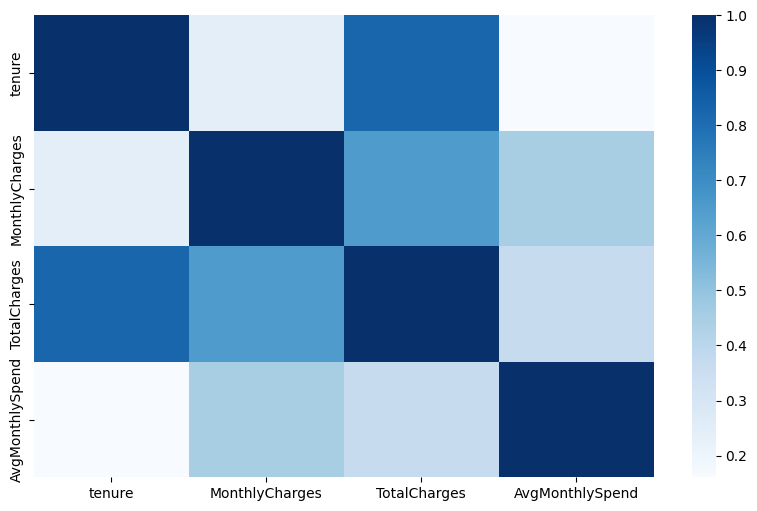

In [34]:
plt.figure(figsize=(10,6))
sns.heatmap(dataset.corr(numeric_only=True), cmap='Blues')
plt.show()

<h5 style="color:darkblue;"> 
• The correlation analysis shows that tenure and Total Charges are strongly positively correlated, indicating that customers with longer tenure accumulate higher total charges.<br> 
• Monthly Charges has a moderate correlation with Total Charges, while Average Monthly Spend also shows expected correlations as it is a derived feature. <br> 
• Although some variables are related, no severe multicollinearity is observed.
</h5>  

### Q14. Is there a significant difference in monthly charges between churned and non-churned customers?

Null Hypothesis (H0): There is no significant difference in monthly charges between churned and non-churned customers.<br>
Alternative Hypothesis (H1): There is a significant difference in monthly charges between churned and non-churned customers.

In [41]:
from scipy.stats import ttest_ind

group1 = dataset[dataset['Churn']=='No']['MonthlyCharges']
group2 = dataset[dataset['Churn']=='Yes']['MonthlyCharges']

ttest_ind(group1, group2)

TtestResult(statistic=-16.536738015936308, pvalue=2.706645606888385e-60, df=7041.0)

<h5 style="color:darkblue;"> 
• The p-value (2.706e-60) is significantly less than 0.05, so we reject the null hypothesis.<br> 
• This indicates that there is a statistically significant difference in monthly charges between churned and non-churned customers.<br>
• Additionally, churned customers tend to have higher average monthly charges, suggesting that higher pricing may contribute to customer churn.</h5>

### Q15. Does Internet service type affect churn?

<Axes: xlabel='Churn', ylabel='InternetService'>

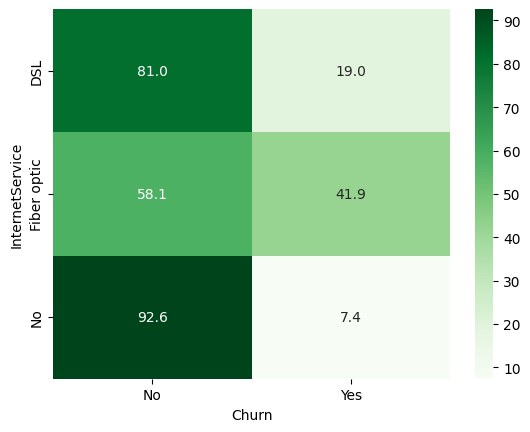

In [44]:
ct = pd.crosstab(dataset['InternetService'], dataset['Churn'], normalize='index') * 100

sns.heatmap(ct, annot=True, fmt='.1f', cmap='Greens')

<h5 style="color:darkblue;"> 
• Customers using fiber optic internet have a higher churn rate compared to DSL and no internet users.<br>
• Customers with no internet service show the lowest churn. <br>
• This indicates that internet service type has a strong influence on customer churn.    
</h5>  

### Q16. Do customers with different contract types pay different monthly charges?

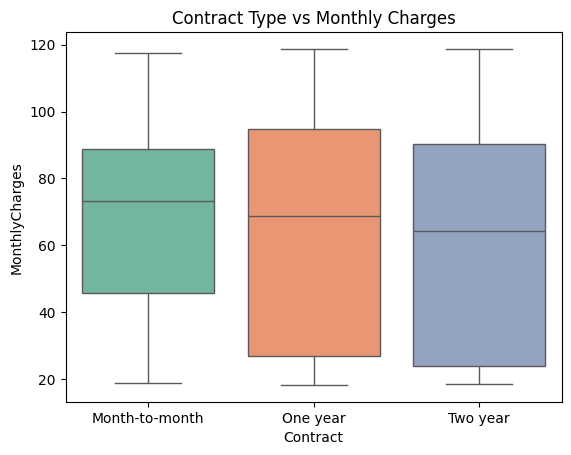

In [69]:
sns.boxplot(x='Contract', y='MonthlyCharges', data=dataset,
            palette='Set2')

plt.title('Contract Type vs Monthly Charges')
plt.show()

<h5 style="color:darkblue;"> 
• Month-to-month customers tend to have slightly higher monthly charges.  <br> 
• One-year and two-year contracts show wider variation in charges. <br> 
• Long-term contract users generally include more lower-charge customers. <br> 
• Overall, pricing varies across contract types, but not extremely different.
</h5>

### Q17. Do long-term customers pay more or less?

<Axes: xlabel='tenure', ylabel='MonthlyCharges'>

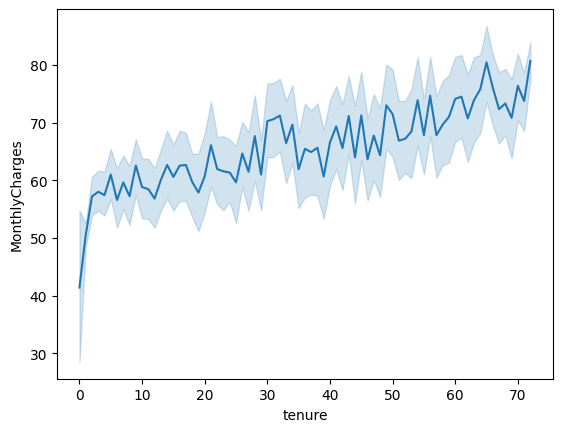

In [56]:
sns.lineplot(x='tenure', y='MonthlyCharges', data=dataset)

<h5 style="color:darkblue;"> 
• Monthly charges slightly increase as tenure increases.<br> 
• New customers start with lower charges.<br> 
• Long-term customers tend to pay a bit higher on average.<br> 
• Shows a gradual upward trend, but not a very strong relationship.
</h5>

### Q18. Do senior citizens churn more?

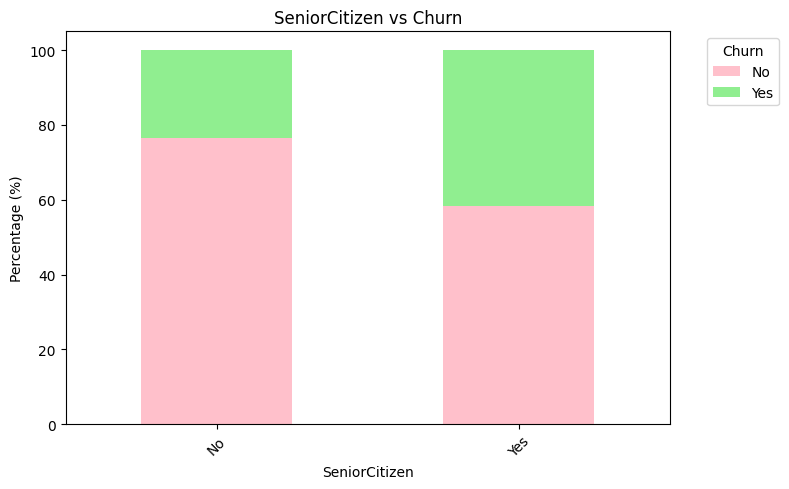

In [61]:
ct.plot(kind='bar', stacked=True, figsize=(8,5),
        color=['pink', 'lightgreen'])

plt.xlabel('SeniorCitizen')
plt.ylabel('Percentage (%)')
plt.title('SeniorCitizen vs Churn')

plt.legend(title='Churn', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45)
    
plt.tight_layout()
plt.show()

<h5 style="color:darkblue;"> 
• Senior citizens have a higher churn percentage compared to non-senior customers.<br>
• Non-senior customers show better retention.<br>
• This indicates senior citizens are more likely to leave the service. <br>
</h5>

### Q19. Does using more services reduce churn?

In [63]:
# Creating Number of Services as a new feature
services = ['PhoneService','MultipleLines','InternetService','OnlineSecurity',
            'OnlineBackup','DeviceProtection','TechSupport','StreamingTV','StreamingMovies']

dataset['NumServices'] = dataset[services].apply(lambda x: (x=='Yes').sum(), axis=1)

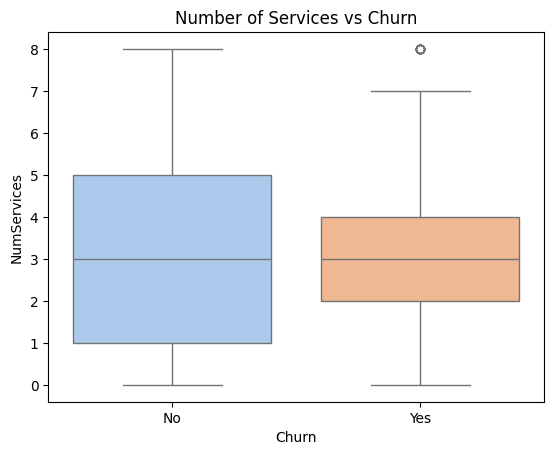

In [71]:
sns.boxplot(x='Churn', y='NumServices', data=dataset,
            palette='pastel')

plt.title('Number of Services vs Churn')
plt.show()

<h5 style="color:darkblue;"> 
• Customers who churn tend to use fewer services. <br> 
• Customers who stay usually have slightly higher number of services. <br> 
• Indicates that using more services may improve customer retention. <br> 
• However, the difference is moderate, not very strong.
</h5>

### Q20. Do payment methods relate to billing amounts?

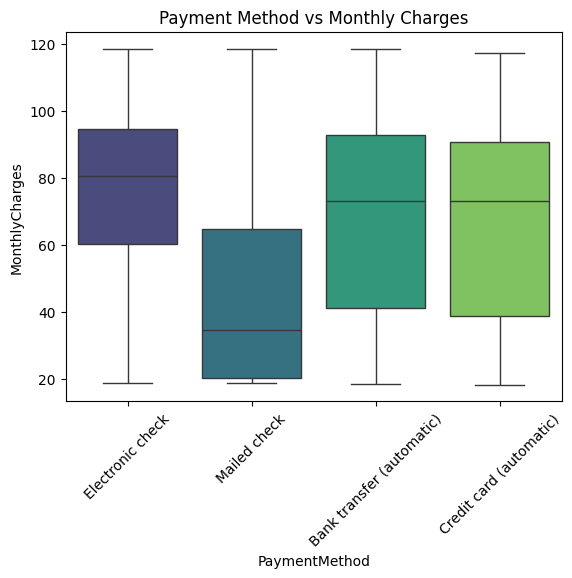

In [78]:
sns.boxplot(x='PaymentMethod', y='MonthlyCharges', data=dataset,
            palette='viridis')

plt.xticks(rotation=45)
plt.title('Payment Method vs Monthly Charges')
plt.show()

<h5 style="color:darkblue;"> 
• Electronic check users tend to have higher monthly charges.<br> 
• Mailed check users have lower monthly charges.<br> 
• Automatic payment methods show moderate to higher charges.<br> 
• Payment method seems to be associated with billing differences
</h5>

In [80]:
df = dataset.copy()

In [81]:
df.to_csv("df.csv", index=False)